In [8]:
#!pip3 install tensorflow_hub

In [123]:
# Basic packages
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2" 
import warnings
warnings.filterwarnings("ignore")
from typing import List, Dict
from PIL import Image
import requests
from tqdm import tqdm

# ds packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import chain

# sklearn packages
from sklearn.base import (TransformerMixin, 
                         BaseEstimator)


# Tensorflow packages
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow_text import (BertTokenizer, 
                               WhitespaceTokenizer)
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, 
                                     Dense,
                                     GlobalAveragePooling2D)
from tensorflow.keras.layers import (Embedding, 
                                     MultiHeadAttention, 
                                     LayerNormalization, 
                                     Dropout)
from tensorflow.keras.layers import (Bidirectional, 
                                     LSTM, 
                                     Conv1D, 
                                     Add, 
                                     GlobalAveragePooling1D)
from tensorflow.keras.applications import ResNet50

# 1. Load the data

## Read the Train - All Question Answer Pairs text file

In [124]:
def load_text_data(file_path: str, sep:str) -> List[Dict]:
    text_data = pd.read_csv(file_path, 
                            sep = sep, 
                            header = None)
    text_data.columns = ["image_id", "question", "answer"]
    print(f"Shape of Text Data : {text_data.shape}")

    text_data_dict = text_data.to_dict(orient = "records") # Convert to a list of dictionaries
    return text_data_dict

train_QA_dict = load_text_data(file_path= "./data/data_VQA/ImageClef-2019-VQA-Med-Training/All_QA_Pairs_train.txt",
         sep = "|")

train_QA_dict[0:2] # display of first 2 records

Shape of Text Data : (12792, 3)


[{'image_id': 'synpic41148',
  'question': 'what kind of image is this?',
  'answer': 'cta - ct angiography'},
 {'image_id': 'synpic43984',
  'question': 'is this a t1 weighted image?',
  'answer': 'no'}]

In [125]:
train_QA_dict[0:10]

[{'image_id': 'synpic41148',
  'question': 'what kind of image is this?',
  'answer': 'cta - ct angiography'},
 {'image_id': 'synpic43984',
  'question': 'is this a t1 weighted image?',
  'answer': 'no'},
 {'image_id': 'synpic38930',
  'question': 'what type of imaging modality is used to acquire the image?',
  'answer': 'us - ultrasound'},
 {'image_id': 'synpic52143',
  'question': 'is this a noncontrast mri?',
  'answer': 'no'},
 {'image_id': 'synpic20934',
  'question': 'what type of image modality is this?',
  'answer': 'xr - plain film'},
 {'image_id': 'synpic19141',
  'question': 'with what modality is this image taken?',
  'answer': 'xr - plain film'},
 {'image_id': 'synpic25502',
  'question': 'what was this image taken with?',
  'answer': 'xr - plain film'},
 {'image_id': 'synpic38317',
  'question': 'is this a contrast or noncontrast ct?',
  'answer': 'noncontrast'},
 {'image_id': 'synpic22829',
  'question': 'was the ct scan taken with contrast?',
  'answer': 'yes'},
 {'imag

#### Notes:

For each image_id, there are four question-answer pairs. 

- 1. Modality, 
- 2. Plane, 
- 3. Organ System 
- 4. Abnormality


### 1. Load and Preprocess the Image Data 

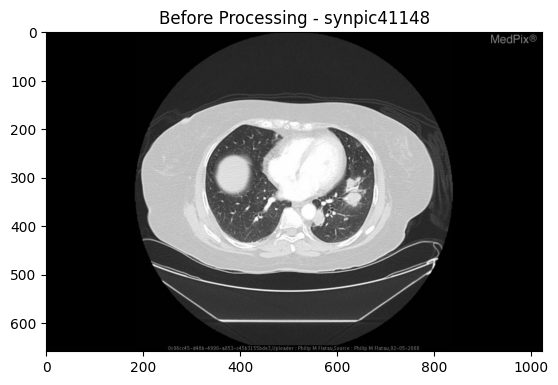

In [126]:
img = Image.open("./data/data_VQA/ImageClef-2019-VQA-Med-Training/Train_images/synpic41148.jpg")
plt.imshow(img)
plt.title("Before Processing - synpic41148")
plt.show()

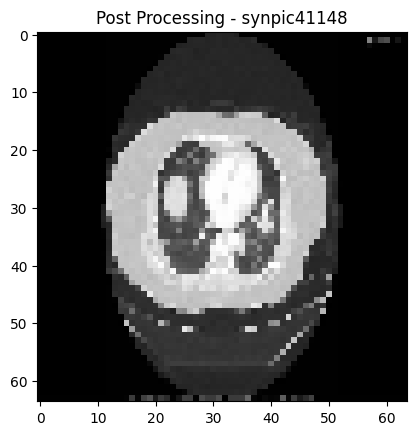

In [127]:
def preprocess_image(image_id, image_dir):

    # load the image
    image_filename = image_id + ".jpg"
    image_path = os.path.join(image_dir, image_filename)

    # basic preprocessing the image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.image.resize(img, [64, 64])
    img = img / 255.0
    img = tf.cast(img, tf.float32)

    return img

img = preprocess_image(image_id = "synpic41148",
                       image_dir = "./data/data_VQA/ImageClef-2019-VQA-Med-Training/Train_images/", 
                 )

plt.imshow(img)
plt.title("Post Processing - synpic41148")
plt.show()

### 2. Text Preprocessing

BertTokenizer

The BertTokenizer mirrors the original implementation of tokenization from the BERT paper. This is backed by the WordpieceTokenizer, but also performs additional tasks such as normalization and tokenizing to words first.

#### 1. Tokenization - Loading Vocabulary

In [71]:
url = "https://github.com/tensorflow/text/blob/master/tensorflow_text/python/ops/test_data/test_wp_en_vocab.txt?raw=true"
r = requests.get(url)
filepath = "vocab.txt"
open(filepath, 'wb').write(r.content)

52382

#### 1. Find out the max length of the Questions, Answers

In [128]:
tokenizer = WhitespaceTokenizer()
max_length_question = 0
for record in tqdm(train_QA_dict):
    question = record["question"]
    tokens = tokenizer.tokenize(question)
    max_length_question = max(max_length_question, tokens.shape[0])


max_length_answer = 0
for record in tqdm(train_QA_dict):
    answer = record["answer"]
    tokens = tokenizer.tokenize(answer)
    max_length_answer = max(max_length_answer, tokens.shape[0])


print(f"Max Length Question: {max_length_question}")
print(f"Max Length Answer: {max_length_answer}")


max_length = {
    "Question" : max_length_question, 
    "Answer" : max_length_answer
}

100%|██████████| 12792/12792 [00:37<00:00, 344.75it/s]

Max Length Question: 11
Max Length Answer: 19


#### 2. Tokenization

In [129]:
tokenizer = BertTokenizer(filepath, 
                          lower_case = True, 
                          token_out_type= tf.int32)

In [130]:
def tokenize_dict(data_dict: List[Dict], 
                  tokenizer, 
                  max_length: Dict) -> List[Dict]:
    
    data_dict_tokenized = []

    for record in tqdm(data_dict):
        
        # Question Tokenization
        question = record["question"]
        question_tokens = tokenizer.tokenize(question).to_list()
        question_tokens= list(chain.from_iterable(chain.from_iterable(question_tokens)))
        question_tokens = pad_sequences([question_tokens], 
                                         maxlen = max_length["Question"]+20, 
                                         dtype = 'int32', 
                                         padding = 'post')

        # Answer Tokenization
        answer = record["answer"]
        answer_tokens = tokenizer.tokenize(answer).to_list()
        answer_tokens= list(chain.from_iterable(chain.from_iterable(answer_tokens)))
        answer_tokens = pad_sequences([answer_tokens], 
                                       maxlen = max_length["Answer"]+20,
                                       dtype = "int32", 
                                       padding = "post")


        data_dict_tokenized.append({
            "image_id": record["image_id"],
            "question": question_tokens,
            "answer": answer_tokens
        })
        

    return data_dict_tokenized

In [131]:
train_QA_tokenized = tokenize_dict(data_dict= train_QA_dict, 
              tokenizer = tokenizer, 
              max_length = max_length)

100%|██████████| 12792/12792 [02:33<00:00, 83.11it/s]


#### 3. Max Vocabulary Size

In [132]:
all_list_question = []
for records in tqdm(train_QA_dict):
    all_list_question.append(records["question"])

all_list_question = " ".join(all_list_question)

max_question_vocab_size = len(set(all_list_question.split(" ")))
print(f"Max Answer Vocabulary Size : {max_question_vocab_size}")

100%|██████████| 12792/12792 [00:00<00:00, 5008264.42it/s]

Max Answer Vocabulary Size : 130


#### 4. Max Answer Vocabulary Size

In [133]:
all_list_answer = []
for records in tqdm(train_QA_dict):
    all_list_answer.append(records["answer"])

all_list_answer = " ".join(all_list_answer)

max_answer_vocab_size = len(set(all_list_answer.split(" ")))
print(f"Max Answer Vocabulary Size : {max_answer_vocab_size}")

100%|██████████| 12792/12792 [00:00<00:00, 5034581.66it/s]

Max Answer Vocabulary Size : 2328


### 3. Create Tensorflow Dataset - Train

In [134]:
def create_tf_dataset(tokenized_data: List[Dict], image_dir: str, batch_size: int):

    def gen():
        for record in tokenized_data:
            img = preprocess_image(image_id = record["image_id"],
                       image_dir = image_dir, 
                 ) 
            question = record["question"].reshape(-1)
            answer = record["answer"].reshape(-1)

            yield (img, question), answer

    # Infer shapes/dtypes for TF
    output_signature = ((
        tf.TensorSpec(shape=(64, 64, 3), dtype=tf.float32),   # Example image shape
        tf.TensorSpec(shape=(31, ), dtype=tf.int32),           # Question tokens    
        ),
            tf.TensorSpec(shape=(39, ), dtype=tf.int32),   # Answer token
    )

    dataset = (tf.data.Dataset.from_generator(gen, output_signature=output_signature).
                batch(batch_size).
                prefetch(tf.data.AUTOTUNE)
    )

    return dataset


train_tf = create_tf_dataset(tokenized_data = train_QA_tokenized, 
                  image_dir = "./data/data_VQA/ImageClef-2019-VQA-Med-Training/Train_images/",
                  batch_size = 32
                  )
        

In [135]:
for batch in train_tf.take(1):
    input, output  = batch
    print("Shape of Images:", input[0].shape)
    print("Shape of Questions:", input[1].shape)
    print("Shape of Answers:", output.shape)

Shape of Images: (32, 64, 64, 3)
Shape of Questions: (32, 31)
Shape of Answers: (32, 39)


# 2. Creating Validation Dataset

In [136]:
# Create Validation QA dictionary
valid_QA_dict = load_text_data(file_path= "./data/data_VQA/ImageClef-2019-VQA-Med-Validation/All_QA_Pairs_val.txt",
         sep = "|")

# Tokenize Validation QA pairs
valid_QA_tokenized = tokenize_dict(data_dict= valid_QA_dict, 
              tokenizer = tokenizer, 
              max_length = max_length)

# Generate Validation tensorflow dataset
valid_tf = create_tf_dataset(tokenized_data = valid_QA_tokenized, 
                  image_dir = "./data/data_VQA/ImageClef-2019-VQA-Med-Validation/Val_images/",
                  batch_size = 32
                  )

Shape of Text Data : (2000, 3)


100%|██████████| 2000/2000 [00:24<00:00, 80.81it/s]


In [137]:
for batch in valid_tf.take(1):
    input, output  = batch
    print("Shape of Images:", input[0].shape)
    print("Shape of Questions:", input[1].shape)
    print("Shape of Answers:", output.shape)

Shape of Images: (32, 64, 64, 3)
Shape of Questions: (32, 31)
Shape of Answers: (32, 39)


# 3. Image Encoder (Using a Pre-trained CNN Model)

In [138]:
class ImageEncoder(Model):
    def __init__(self):
        super(ImageEncoder, self).__init__()
        self.base_model = ResNet50(include_top = False,
                                   weights = "imagenet", 
                                   input_shape = (64, 64, 3)
                                   )
        
        self.base_model.trainable = False
        # Global Average Pooling layer
        self.global_avg_pool = GlobalAveragePooling2D()

        # Output layer
        self.output_layer = Dense(256, activation = "softmax")
    

    def call(self, inputs):
        x = self.base_model(inputs)

        # Global average pooling to flatten the features
        x = self.global_avg_pool(x)

        # Output layer
        x = self.output_layer(x)
        
        return x         

In [139]:
img_encoder = ImageEncoder()
img_encoder.summary()

Model: "image_encoder_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [140]:
# Take one batch from dataset
for batch in train_tf.take(1):
    (images, questions), answers = batch   # unpack inputs and outputs
    
    print("Shape of Images:", images.shape)
    print("Shape of Questions:", questions.shape)
    print("Shape of Answers:", answers.shape)

    # Initialize ImageEncoder
    image_encoder = ImageEncoder()  
    
    # Run model on a small subset (say first 2 images)
    sample_images = images[:2]  
    encoded_output = image_encoder(sample_images)



    print("Input image batch shape:", sample_images.shape)
    print("Output encoded shape:", encoded_output.shape)


Shape of Images: (32, 64, 64, 3)
Shape of Questions: (32, 31)
Shape of Answers: (32, 39)
Input image batch shape: (2, 64, 64, 3)
Output encoded shape: (2, 256)


# 4. Build the Text Encoder (Embedding Layer)

In [83]:
# Load Pretrained BERT Model
encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4", trainable=True)

In [141]:
class QuestionAttention(Model):
    def __init__(self, vocab_size):
        super(QuestionAttention, self).__init__()
    

        # BERT Encoder (pass the encoder instance when creating the model)
        # self.encoder = encoder  
        self.embedding_layer = tf.keras.layers.Embedding(vocab_size, 128, name = "embedding_layer")

        # LSTM layer
        self.lstm = Bidirectional(LSTM(256, return_sequences=True))

        # Convolutional layers
        self.conv_layer_1 = Conv1D(filters=128, kernel_size=3, padding="same", activation="relu")
        self.conv_layer_1 = Conv1D(filters=256, kernel_size=3, padding="same", activation="relu")
        self.conv_layer_2 = Conv1D(filters=512, kernel_size=5, padding="same", activation="relu")

        # Global Average Pooling (1D since it's sequences, not 2D images)
        self.global_avg_pool = GlobalAveragePooling1D()

        # Output layer (change softmax units = vocab size or num_classes later)
        self.output_layer = Dense(256, activation="softmax")

    def call(self, inputs):
        # Get BERT embeddings
        #x = self.encoder(tf.squeeze(inputs, axis = 1))["last_hidden_state"]  # (batch, seq_len, hidden)
        x = self.embedding_layer(inputs)

        # LSTM layer
        lstm_output = self.lstm(x)

        # Convolutional layers
        x = self.conv_layer_1(lstm_output)
        x = self.conv_layer_2(x)

        # Skip Connection
        x = Add()([lstm_output, x])

        # Global Average Pooling
        x = self.global_avg_pool(x)

        # Output layer
        out = self.output_layer(x)

        return out


In [143]:
for batch in valid_tf.take(1):
    (img, ques), ans = batch  # assuming dataset yields ((image, question), answer)
    print("Image shape:", img.shape)
    print("Question shape:", ques.shape)
    print("Answer shape:", ans.shape)

    model = QuestionAttention(vocab_size= max_question_vocab_size)
    output = model(ques)  # only pass question to this model
    print("Model Output shape:", output.shape)


Image shape: (32, 64, 64, 3)
Question shape: (32, 31)
Answer shape: (32, 39)
Model Output shape: (32, 256)


# 5. Build Decoder Architecture

In [86]:
def create_look_ahead_mask(seq_len):
    """Create a mask to mask future tokens in the decoder."""
    mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
    return mask  # 1s where future tokens are masked

In [144]:
class AnswerDecoder(Model):
    def __init__(self, embedding_dim, hidden_dim_attn, vocab_size, num_heads_attn, ff_dim, dropout_rate = 0.3):
        super(AnswerDecoder, self).__init__()

        # Answer embedding layer
        self.answer_embedding = Embedding(input_dim = vocab_size, 
                                          output_dim = embedding_dim, 
                                          )
        
        # Decoder layers
        self.self_attn = MultiHeadAttention(num_heads=num_heads_attn, key_dim=hidden_dim_attn)
        self.cross_attn = MultiHeadAttention(num_heads=num_heads_attn, key_dim=hidden_dim_attn)
        self.norm1 = LayerNormalization()
        self.norm2 = LayerNormalization()
        self.norm3 = LayerNormalization()
        

        # Feed Forward networks
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(hidden_dim_attn),
        ])

        self.dropout = Dropout(dropout_rate)

        # Output projection to vocabulary
        self.output_layer = Dense(vocab_size, activation='softmax')


    def call(self, decoder_input, encoder_feat, training=False):
        
        # Embedding
        x = self.answer_embedding(decoder_input) 
       
        # Masked Self-Attention
        seq_len = tf.shape(x)[1]
        look_ahead_mask = create_look_ahead_mask(seq_len)[tf.newaxis, tf.newaxis, :, :]  # add batch & head dims
        
        self_attn_output = self.self_attn(query=x, value=x, key=x, attention_mask=look_ahead_mask)
        x = self.norm1(self_attn_output + x)
        
        # Cross-Attention with encoder features
        cross_attn_output = self.cross_attn(query=x, value=encoder_feat, key=encoder_feat)
        x = self.norm2(cross_attn_output + x)
        
        # Feed-forward
        ffn_output = self.ffn(x)
        x = self.norm3(ffn_output + x)
        x = self.dropout(x, training=training)
        
        
        logits = self.output_layer(x)  # (batch, ans_seq_len, vocab_size)
        return logits


In [146]:
for batch in train_tf.take(1):

    (img, ques), ans = batch  # assuming dataset yields ((image, question), answer)
    print("Image shape:", img.shape)
    print("Question shape:", ques.shape)
    print("Answer shape:", ans.shape)
    # Example: encoder features
    img_feat = ImageEncoder()(img)        # (batch, img_dim)
    ques_feat = QuestionAttention( vocab_size= max_question_vocab_size)(ques)  # (batch, ques_dim)

    # Project to hidden_dim and stack as encoder sequence
    encoder_feat = tf.stack([img_feat, ques_feat], axis=1)  # (batch, 2, hidden_dim)

    # Decoder input: teacher forcing
    decoder_input = answers[:, :-1]  # (batch, ans_seq_len-1)

    # Pass through decoder
    decoder = AnswerDecoder(embedding_dim = 512, 
                            hidden_dim_attn = 512, 
                            vocab_size = max_answer_vocab_size, 
                            num_heads_attn = 8, 
                            ff_dim = 512)
    logits = decoder(decoder_input, encoder_feat)


Image shape: (32, 64, 64, 3)
Question shape: (32, 31)
Answer shape: (32, 39)


In [147]:
decoder.summary()

Model: "answer_decoder_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (32, 38, 512)          │     1,191,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_head_attention_10         │ (32, 38, 512)          │     8,401,408 │
│ (MultiHeadAttention)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_head_attention_11         │ (32, 38, 512)          │     6,304,256 │
│ (MultiHeadAttention)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_15          │ (32, 38, 512)          │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_16          │ (32, 38, 512)          │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_17          │ (32, 38, 512)          │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (32, 38, 512)          │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (32, 38, 2328)         │     1,194,264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,620,248 (67.22 MB)

 Trainable params: 17,620,248 (67.22 MB)

 Non-trainable params: 0 (0.00 B)

In [148]:
vocab_size

{'max_question_vocab_size': 130, 'max_answer_vocab_size': 2328}

In [152]:
class VQATransformer(Model):
    def __init__(self, vocab_size, embedding_dim=256, hidden_dim_attn=256, num_heads_attn=8, ff_dim=512, dropout_rate=0.3):
        super(VQATransformer, self).__init__()

        # Image encoder
        self.image_encoder = ImageEncoder()

        # Question encoder
        self.question_encoder = QuestionAttention(vocab_size=vocab_size["max_question_vocab_size"])

        # Answer decoder
        self.answer_decoder = AnswerDecoder(
            embedding_dim=embedding_dim,
            hidden_dim_attn=hidden_dim_attn,
            vocab_size=vocab_size["max_answer_vocab_size"],
            num_heads_attn=num_heads_attn,
            ff_dim=ff_dim,
            dropout_rate=dropout_rate
        )

        # Final layer (optional fusion if needed)
        self.fc = Dense(vocab_size, activation="softmax")

    def call(self, image_inputs, question_inputs, answer_inputs, training=False):
        # 1. Encode Image
        img_features = self.image_encoder(image_inputs)       # (batch, 256)

        # 2. Encode Question
        ques_features = self.question_encoder(question_inputs) # (batch, 256)

        # 3. Concatenate image + question features
        encoder_features = tf.concat([img_features, ques_features], axis=-1)  # (batch, 512)

        # Expand dims so cross-attn sees it as sequence
        encoder_features = tf.expand_dims(encoder_features, axis=1)           # (batch, 1, 512)

        # 4. Decode Answer sequence (teacher forcing during training)
        logits = self.answer_decoder(answer_inputs, encoder_features, training=training) # (batch, seq_len, vocab_size)

        return logits


In [153]:
vocab_size = {
    "max_question_vocab_size": max_question_vocab_size,
    "max_answer_vocab_size": max_answer_vocab_size
}

In [154]:
model = VQATransformer(vocab_size=vocab_size)
model.summary()

Model: "vqa_transformer_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_encoder_13 (ImageEncoder) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ question_attention_9            │ ?                      │   0 (unbuilt) │
│ (QuestionAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ answer_decoder_6                │ ?                      │   0 (unbuilt) │
│ (AnswerDecoder)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

# Compile the model

In [155]:
class VQAModel(tf.keras.Model):
    def __init__(self, vqa_transformer, loss_fn):
        super().__init__()
        self.vqa_transformer = vqa_transformer
        self.loss_fn = loss_fn

    def train_step(self, data):
        (img, ques), ans = data
        decoder_in = ans[:, :-1]
        target_out = ans[:, 1:]

        with tf.GradientTape() as tape:
            logits = self.vqa_transformer(img, ques, decoder_in, training=True)
            loss = self.loss_fn(target_out, logits)

        grads = tape.gradient(loss, self.vqa_transformer.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.vqa_transformer.trainable_variables))

        return {"loss": loss}

    def test_step(self, data):
        (img, ques), ans = data
        decoder_in = ans[:, :-1]
        target_out = ans[:, 1:]

        logits = self.vqa_transformer(img, ques, decoder_in, training=False)
        loss = self.loss_fn(target_out, logits)
        return {"loss": loss}


# Compile the Model

In [156]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)

vqa_wrapper = VQAModel(model, loss_fn)  # wrap your VQATransformer
vqa_wrapper.compile(optimizer=tf.keras.optimizers.Adam(1e-4))


# Add Callbacks

In [157]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="artifacts/vqa_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]


# 4. Train with fit

In [158]:
history = vqa_wrapper.fit(
    train_tf,
    validation_data=valid_tf,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
    400/Unknown 112s 240ms/step - loss: 0.7083

2025-08-31 17:42:08.837853: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7812372634143114272
2025-08-31 17:42:08.837882: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 2848465449094759782
2025-08-31 17:42:08.837900: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 16368788417897055516
2025-08-31 17:42:08.837905: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8146361535432820546
2025-08-31 17:42:08.837914: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14697159211166124650
2025-08-31 17:42:08.837917: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6695226167585213360
2025-08-31 17:42:08.837929: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv i


Epoch 1: val_loss improved from inf to 0.00000, saving model to artifacts/vqa_model.keras


2025-08-31 17:42:21.790370: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10713739394307785194
2025-08-31 17:42:21.790391: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 2878937471605924301
2025-08-31 17:42:21.790398: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12409883028213649187
2025-08-31 17:42:21.790402: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 3793163948543346239
2025-08-31 17:42:21.790405: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10334330375214926289
2025-08-31 17:42:21.790409: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7628856672072745876
2025-08-31 17:42:21.790413: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv 

400/400 ━━━━━━━━━━━━━━━━━━━━ 126s 274ms/step - loss: 0.7066 - val_loss: 0.0000e+00
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - loss: 0.3169

...

2025-08-31 17:45:56.462430: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 3292485032503848830
2025-08-31 17:45:56.462447: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10713739394307785194
2025-08-31 17:45:56.462459: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 218030620571292476
2025-08-31 17:45:56.462462: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 3660313670739169517
2025-08-31 17:45:56.462470: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12063446495490229308
2025-08-31 17:45:56.462472: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 2878937471605924301
2025-08-31 17:45:56.462475: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv it

400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - loss: 0.2495

2025-08-31 17:47:31.419928: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1517202499282797122
2025-08-31 17:47:31.419958: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7812372634143114272
2025-08-31 17:47:31.419963: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 2848465449094759782
2025-08-31 17:47:31.419988: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 16368788417897055516
2025-08-31 17:47:31.419998: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8146361535432820546
2025-08-31 17:47:31.420009: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7911634629443514486
2025-08-31 17:47:31.420013: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv it


Epoch 4: val_loss did not improve from 0.00000
400/400 ━━━━━━━━━━━━━━━━━━━━ 104s 261ms/step - loss: 0.2489 - val_loss: 0.0000e+00


2025-08-31 17:47:40.838427: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2025-08-31 17:47:40.838458: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 2878937471605924301
2025-08-31 17:47:40.838462: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 12222435872441706095
2025-08-31 17:47:40.838466: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 2354395211846397950
2025-08-31 17:47:40.838476: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 3793163948543346239
2025-08-31 17:47:40.838479: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10713739394307785194
2025-08-31 17:47:40.838481: I tensorflow/core/framework/local_rendezv

In [171]:
from src.Predictor import VQAEvaluator

In [179]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


class VQAInference:
    def __init__(self, model, tokenizer, start_token=1, end_token=2):
        """
        Initialize VQA inference class.
        
        Args:
            model: VQATransformer model
            tokenizer: Tokenizer for converting tokens to text
            start_token: int (ID for <sos>)
            end_token: int (ID for <eos>)
        """
        self.model = model
        self.tokenizer = tokenizer
        self.start_token = start_token
        self.end_token = end_token
    
    def greedy_decode(self, img, ques, max_len=15):
        """
        Perform greedy decoding for VQA.
        
        Args:
            img: (1, 64, 64, 3) - input image
            ques: (1, q_len) - input question tokens
            max_len: maximum sequence length for answer
            
        Returns:
            ans_seq: list of predicted token IDs
        """
        ans_seq = [self.start_token]
        
        for _ in range(max_len):
            decoder_in = tf.expand_dims(ans_seq, axis=0)  # (1, cur_len)
            logits = self.model(img, ques, decoder_in, training=False)  # (1, cur_len, vocab_size)
            next_token = tf.argmax(logits[:, -1, :], axis=-1).numpy()[0]
            ans_seq.append(next_token)
            
            if next_token == self.end_token:
                break
                
        return ans_seq
    
    def predict(self, img, ques, max_len=15):
        """
        Generate prediction and convert to text.
        
        Args:
            img: (1, 64, 64, 3) - input image
            ques: (1, q_len) - input question tokens
            max_len: maximum sequence length for answer
            
        Returns:
            pred_text: predicted answer as text
            pred_tokens: predicted tokens as numpy array
        """
        pred_tokens = self.greedy_decode(img, ques, max_len)
        pred_tokens = np.array([int(t) for t in pred_tokens])
        pred_text = self.tokenizer.detokenize(pred_tokens.reshape((1, -1)))
        
        return pred_text, pred_tokens
    
    def visualize_sample(self, img_batch, ques_batch, ans_batch, sample_idx=0, max_len=15):
        """
        Visualize a VQA sample with prediction and ground truth.
        
        Args:
            img_batch: batch of images
            ques_batch: batch of questions
            ans_batch: batch of answers
            sample_idx: index of sample to visualize
            max_len: maximum sequence length for answer
        """
        # Extract single sample
        img = img_batch[sample_idx:sample_idx+1]  # (1, 64, 64, 3)
        ques = ques_batch[sample_idx:sample_idx+1]  # (1, q_len)
        ans_true = ans_batch[sample_idx].numpy()
        
        # Generate prediction
        pred_text, pred_tokens = self.predict(img, ques, max_len)
        
        # Convert true answer to text
        true_text = self.tokenizer.detokenize(ans_true.reshape((1, -1)))
        question_text = self.tokenizer.detokenize(ques[0].numpy().reshape((1, -1)))
        
        # Visualize
        plt.imshow(img[0])
        plt.axis("off")
        plt.title("VQA Sample")
        plt.show()
        
        print("Question:", question_text)
        print("True Answer:", true_text)
        print("Predicted Answer:", pred_text)
        
        return {
            'question': question_text,
            'true_answer': true_text,
            'predicted_answer': pred_text,
            'predicted_tokens': pred_tokens
        }
    
    def evaluate_sample_from_dataset(self, dataset, max_len=15):
        """
        Take one sample from dataset and evaluate.
        
        Args:
            dataset: TensorFlow dataset (e.g., train_tf)
            max_len: maximum sequence length for answer
            
        Returns:
            evaluation results dictionary
        """
        # Take one sample
        for (img_batch, ques_batch), ans_batch in dataset.take(1):
            return self.visualize_sample(img_batch, ques_batch, ans_batch, 
                                       sample_idx=0, max_len=max_len)


# Usage example:
# vqa_inference = VQAInference(model, tokenizer, start_token=1, end_token=2)
# results = vqa_inference.evaluate_sample_from_dataset(train_tf, max_len=max_length["Answer"])

In [182]:
evaluator = VQAInference(vqa_wrapper, 
                         tokenizer,
                             start_token=1, 
                             end_token=2, 
                             )

In [ ]:
def greedy_decode(model, img, ques, start_token, end_token, max_len=15):
    """
    model: VQATransformer
    img: (1, 64, 64, 3)
    ques: (1, q_len)
    start_token: int (ID for <sos>)
    end_token: int (ID for <eos>)
    """
    ans_seq = [start_token]

    for _ in range(max_len):
        decoder_in = tf.expand_dims(ans_seq, axis=0)  # (1, cur_len)

        logits = model(img, ques, decoder_in, training=False)  # (1, cur_len, vocab_size)
        next_token = tf.argmax(logits[:, -1, :], axis=-1).numpy()[0]

        ans_seq.append(next_token)
        if next_token == end_token:
            break

    return ans_seq


In [98]:
def tokens_to_text(tokens, idx2word):
    return " ".join([idx2word[t] for t in tokens if t not in [0]])  # skip PAD


In [165]:
import matplotlib.pyplot as plt

# Take one sample
for (img_batch, ques_batch), ans_batch in train_tf.take(1):
    img = img_batch[0:1]        # (1, 64, 64, 3)
    ques = ques_batch[0:1]      # (1, q_len)
    ans_true = ans_batch[0].numpy()
    break


In [166]:
# Define start/end tokens (adapt to your tokenizer)
START_TOKEN, END_TOKEN = 1, 2  

pred_tokens = greedy_decode(model, img, ques, START_TOKEN, END_TOKEN, max_len=max_length["Answer"])

pred_tokens = np.array([int(t) for t in pred_tokens])
# Convert tokens → words
pred_text = tokenizer.detokenize(pred_tokens.reshape((1, -1)))
true_text = tokenizer.detokenize(ans_true.reshape((1, -1)))


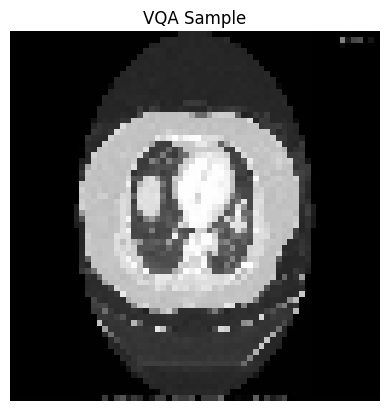

Question: <tf.RaggedTensor [[b'what', b'kind', b'of', b'image', b'is', b'this', b'?', b'[PAD]',
  b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]',
  b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]',
  b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]',
  b'[PAD]', b'[PAD]']]>
True Answer: <tf.RaggedTensor [[b'cta', b'-', b'ct', b'angiography', b'[PAD]', b'[PAD]', b'[PAD]',
  b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]',
  b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]',
  b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]',
  b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]']]>
Predicted Answer: <tf.RaggedTensor [[b'[UNK]s', b',', b'ple', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]',
  b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]',
  b'[PAD]', b'[PAD]', b'[PAD]', b'[PAD]']]>


In [167]:
plt.imshow(img[0])
plt.axis("off")
plt.title("VQA Sample")
plt.show()

print("Question:", tokenizer.detokenize(ques[0].numpy().reshape((1, -1))))
print("True Answer:", true_text)
print("Predicted Answer:", pred_text)
